# Détection de Tweets Suspects
## Partie 1 : Exploration et Prétraitement des Données

**Objectif :** Réaliser une analyse exploratoire complète et un prétraitement rigoureux du dataset de tweets pour préparer la phase de modélisation.



### Plan du notebook
1. [Importation des bibliothèques](#1)
2. [Chargement et inspection des données](#2)
3. [Analyse exploratoire (EDA)](#3)
4. [Prétraitement du texte](#4)
5. [Analyse post-prétraitement](#5)
6. [Sauvegarde des données prétraitées](#6)

<a id='1'></a>
## 1. Importation des bibliothèques

In [3]:
# ─── Manipulation des données ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# ─── NLP ────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# ─── Configuration ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style global des graphiques
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Palette de couleurs
COLORS = {'suspect': '#E74C3C', 'normal': '#2ECC71', 'accent': '#3498DB'}
PALETTE = [COLORS['normal'], COLORS['suspect']]

print('Bibliothèques importées avec succès')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   nltk    : {nltk.__version__}')

Bibliothèques importées avec succès
   pandas  : 2.2.2
   numpy   : 2.0.2
   nltk    : 3.9.1


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<a id='2'></a>
## 2. Chargement et inspection des données

In [5]:
# ── Chargement ──────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/construction de modeles et leur deploiement/tweets.csv'
df = pd.read_csv(DATA_PATH)

print('=' * 60)
print('APERÇU DU DATASET')
print('=' * 60)
print(f'  Dimensions       : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'  Colonnes         : {df.columns.tolist()}')
print()
df.head(10)

APERÇU DU DATASET
  Dimensions       : 60000 lignes × 2 colonnes
  Colonnes         : ['message', 'label']



,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1
5,@Kwesidei not the whole crew,1
6,Need a hug,1
7,@LOLTrish hey long time no see! Yes.. Rains a...,1
8,@Tatiana_K nope they didn't have it,1
9,@twittera que me muera ?,1


In [6]:
# ── Types et informations générales ─────────────────────────────────────────
print('INFORMATIONS SUR LE DATASET')
print('-' * 60)
df.info()

INFORMATIONS SUR LE DATASET
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  60000 non-null  object
 1   label    60000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 937.6+ KB


In [7]:
# ── Statistiques descriptives ───────────────────────────────────────────────
print('STATISTIQUES DESCRIPTIVES')
print('-' * 60)
df.describe(include='all')

STATISTIQUES DESCRIPTIVES
------------------------------------------------------------


,message,label
count,60000,60000.000000
unique,59703,NaN
top,#NAME?,NaN
freq,7,NaN
mean,NaN,0.897583
std,NaN,0.303198
min,NaN,0.000000
25%,NaN,1.000000
50%,NaN,1.000000
75%,NaN,1.000000


In [8]:
# ── Valeurs manquantes ───────────────────────────────────────────────────────
print('ANALYSE DES VALEURS MANQUANTES')
print('-' * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})
print(missing_df)
print()
if missing.sum() == 0:
    print('Aucune valeur manquante détectée — dataset complet.')
else:
    print(f'{missing.sum()} valeurs manquantes à traiter.')

# ── Doublons ────────────────────────────────────────────────────────────────
n_duplicates = df.duplicated(subset='message').sum()
print(f'\n Tweets dupliqués : {n_duplicates}')
if n_duplicates > 0:
    df = df.drop_duplicates(subset='message').reset_index(drop=True)
    print(f'   → Supprimés. Nouveau total : {len(df)} tweets')

ANALYSE DES VALEURS MANQUANTES
------------------------------------------------------------
         Valeurs manquantes  Pourcentage (%)
message                   0              0.0
label                     0              0.0

Aucune valeur manquante détectée — dataset complet.

 Tweets dupliqués : 297
   → Supprimés. Nouveau total : 59703 tweets


<a id='3'></a>
## 3. Analyse Exploratoire des Données (EDA)

In [9]:
# ── 3.1 Distribution des classes ────────────────────────────────────────────
label_counts = df['label'].value_counts()
label_names = {0: 'Normal', 1: 'Suspect'}
label_pct = (label_counts / len(df) * 100).round(1)

print('DISTRIBUTION DES CLASSES')
print('-' * 40)
for lbl, cnt in label_counts.items():
    pct = label_pct[lbl]
    bar = '█' * int(pct / 2)
    print(f'  {label_names[lbl]:8s} (label={lbl}) : {cnt:5d} tweets ({pct:.1f}%)  {bar}')

ratio = label_counts[1] / label_counts[0]
print(f'\n  Ratio Suspect/Normal : {ratio:.2f}')
if ratio > 1.5 or ratio < 0.67:
    print('Déséquilibre des classes détecté → traitement nécessaire (Partie 4)')
else:
    print('Classes relativement équilibrées')

DISTRIBUTION DES CLASSES
----------------------------------------
  Suspect  (label=1) : 53573 tweets (89.7%)  ████████████████████████████████████████████
  Normal   (label=0) :  6130 tweets (10.3%)  █████

  Ratio Suspect/Normal : 8.74
Déséquilibre des classes détecté → traitement nécessaire (Partie 4)


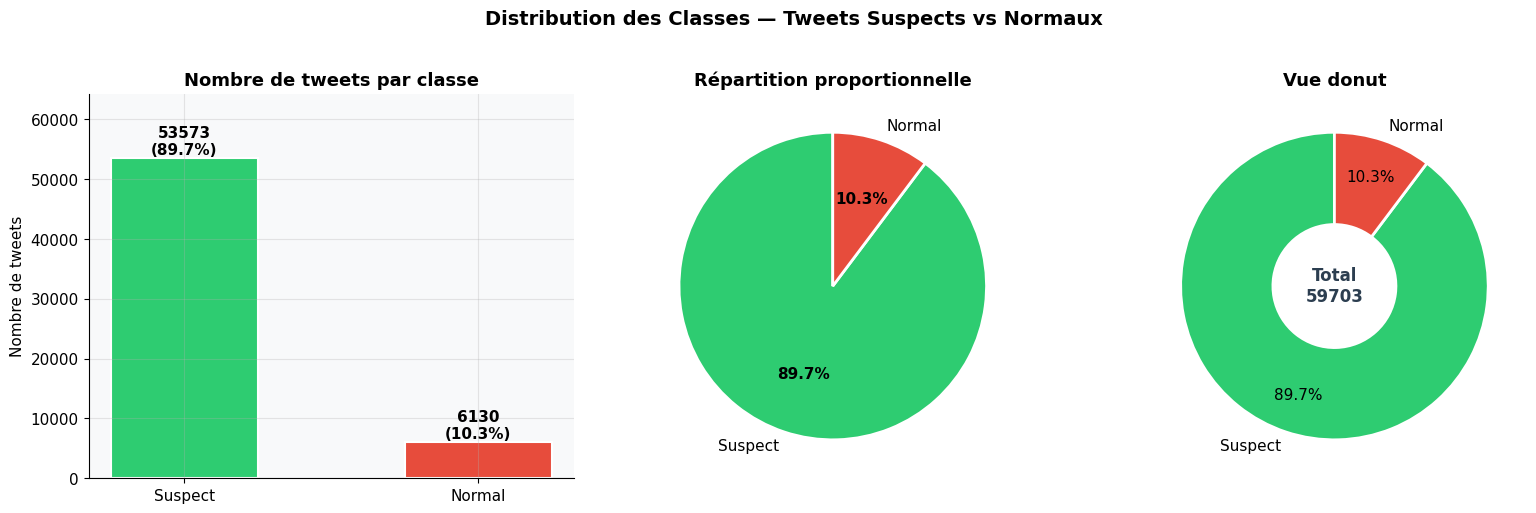

Figure 1 sauvegardée


In [12]:
# ── Figure 1 : Distribution des classes ─────────────────────────────────────
import os

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution des Classes — Tweets Suspects vs Normaux', fontsize=14, fontweight='bold', y=1.02)

# Barplot
ax1 = axes[0]
bars = ax1.bar([label_names[k] for k in label_counts.index],
               label_counts.values,
               color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{cnt}\n({pct}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Nombre de tweets par classe')
ax1.set_ylabel('Nombre de tweets')
ax1.set_ylim(0, max(label_counts.values) * 1.2)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    label_counts.values,
    labels=[label_names[k] for k in label_counts.index],
    colors=PALETTE,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Répartition proportionnelle')

# Donut
ax3 = axes[2]
wedges2, texts2, autotexts2 = ax3.pie(
    label_counts.values,
    labels=[label_names[k] for k in label_counts.index],
    colors=PALETTE,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6}
)
ax3.text(0, 0, f'Total\n{len(df)}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#2C3E50')
ax3.set_title('Vue donut')

plt.tight_layout()

output_dir = '/content/reports/figures/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'fig1_distribution_classes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 sauvegardée')

In [13]:
# ── 3.2 Analyse de la longueur des tweets ────────────────────────────────────
df['tweet_length']    = df['message'].apply(len)
df['word_count']      = df['message'].apply(lambda x: len(str(x).split()))
df['char_count']      = df['message'].apply(lambda x: len(str(x).replace(' ', '')))
df['avg_word_len']    = df['char_count'] / df['word_count'].replace(0, 1)
df['hashtag_count']   = df['message'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['mention_count']   = df['message'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['url_count']       = df['message'].apply(lambda x: len(re.findall(r'http\S+|www\.\S+', str(x))))
df['uppercase_ratio'] = df['message'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df['exclamation_count'] = df['message'].apply(lambda x: str(x).count('!'))
df['question_count']    = df['message'].apply(lambda x: str(x).count('?'))

print('STATISTIQUES DE LONGUEUR PAR CLASSE')
print('=' * 65)
stats_cols = ['tweet_length', 'word_count', 'hashtag_count', 'mention_count',
              'url_count', 'uppercase_ratio', 'exclamation_count']

for col in stats_cols:
    s0 = df[df['label']==0][col].mean()
    s1 = df[df['label']==1][col].mean()
    print(f'  {col:<22s}  Normal: {s0:6.2f}   Suspect: {s1:6.2f}')

STATISTIQUES DE LONGUEUR PAR CLASSE
  tweet_length            Normal:  86.64   Suspect:  72.41
  word_count              Normal:  15.57   Suspect:  12.85
  hashtag_count           Normal:   0.02   Suspect:   0.02
  mention_count           Normal:   0.38   Suspect:   0.48
  url_count               Normal:   0.04   Suspect:   0.04
  uppercase_ratio         Normal:   0.04   Suspect:   0.04
  exclamation_count       Normal:   0.57   Suspect:   0.54


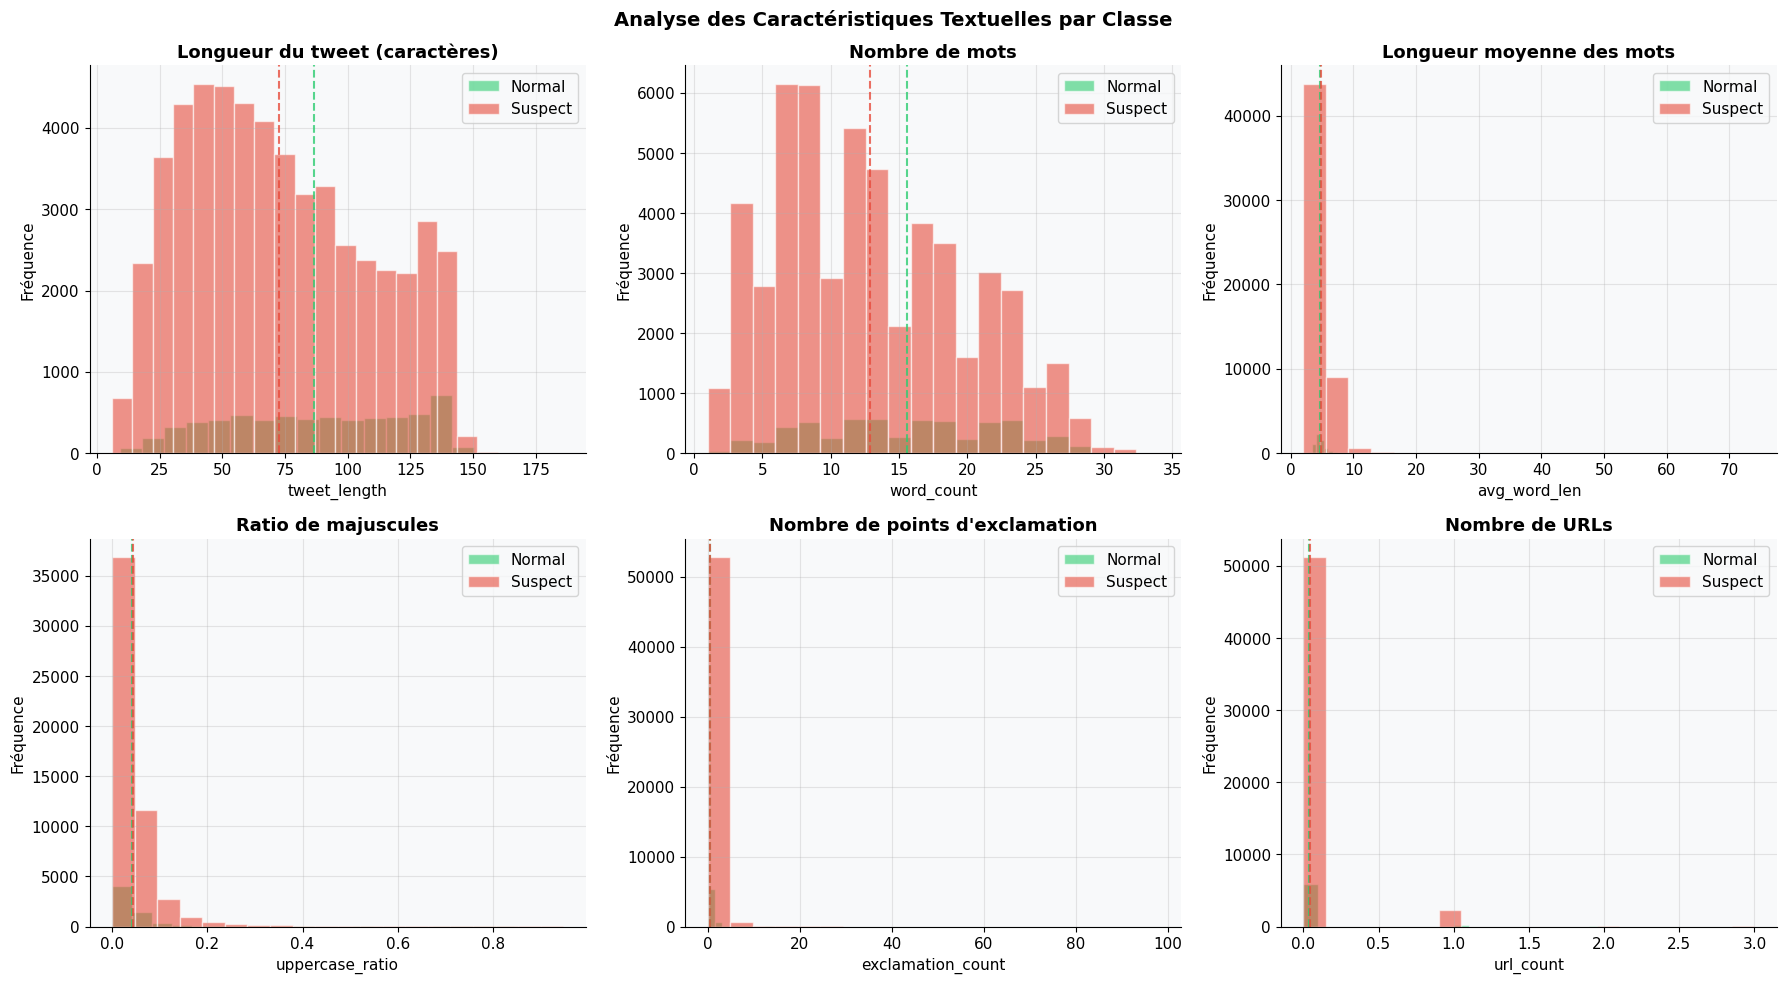

Figure 2 sauvegardée


In [15]:
# ── Figure 2 : Analyse de longueur ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse des Caractéristiques Textuelles par Classe', fontsize=14, fontweight='bold')

plot_configs = [
    ('tweet_length',      'Longueur du tweet (caractères)', axes[0, 0]),
    ('word_count',        'Nombre de mots',                 axes[0, 1]),
    ('avg_word_len',      'Longueur moyenne des mots',      axes[0, 2]),
    ('uppercase_ratio',   'Ratio de majuscules',            axes[1, 0]),
    ('exclamation_count', 'Nombre de points d\'exclamation', axes[1, 1]),
    ('url_count',         'Nombre de URLs',                 axes[1, 2]),
]

for col, title, ax in plot_configs:
    for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
        subset = df[df['label'] == lbl][col]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.legend()
    # Ligne verticale pour la moyenne
    for lbl, color in [(0, COLORS['normal']), (1, COLORS['suspect'])]:
        mean_val = df[df['label'] == lbl][col].mean()
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5, alpha=0.8)

plt.tight_layout()
plt.savefig('/content/reports/figures/fig2_analyse_longueur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 sauvegardée')

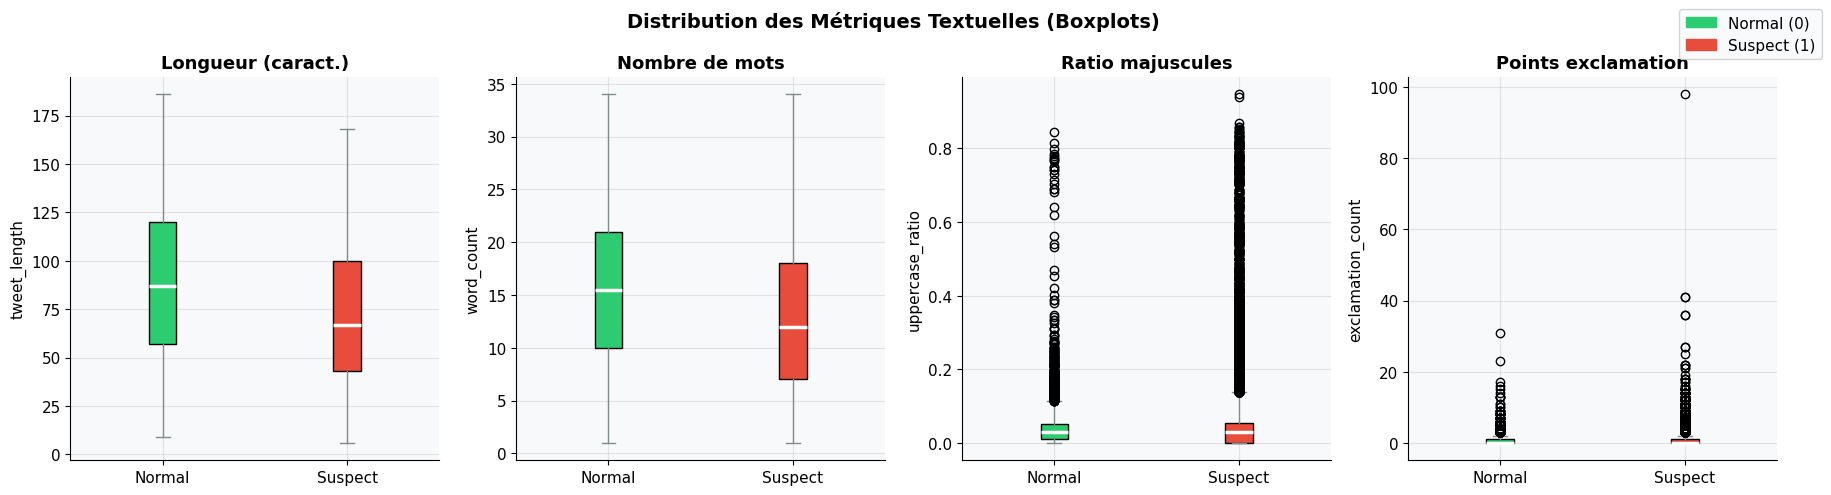

Figure 3 sauvegardée


In [16]:
# ── Figure 3 : Boxplots comparatifs ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribution des Métriques Textuelles (Boxplots)', fontsize=14, fontweight='bold')

box_configs = [
    ('tweet_length',      'Longueur (caract.)'),
    ('word_count',        'Nombre de mots'),
    ('uppercase_ratio',   'Ratio majuscules'),
    ('exclamation_count', 'Points exclamation'),
]

for (col, title), ax in zip(box_configs, axes):
    data_to_plot = [df[df['label']==0][col], df[df['label']==1][col]]
    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2.5})
    bp['boxes'][0].set_facecolor(COLORS['normal'])
    bp['boxes'][1].set_facecolor(COLORS['suspect'])
    for element in ['whiskers', 'caps', 'fliers']:
        for item in bp[element]:
            item.set_color('#7F8C8D')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Normal', 'Suspect'])
    ax.set_title(title)
    ax.set_ylabel(col)

# Légende
normal_patch  = mpatches.Patch(color=COLORS['normal'],  label='Normal (0)')
suspect_patch = mpatches.Patch(color=COLORS['suspect'], label='Suspect (1)')
fig.legend(handles=[normal_patch, suspect_patch], loc='upper right', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('/content/reports/figures/fig3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 sauvegardée')

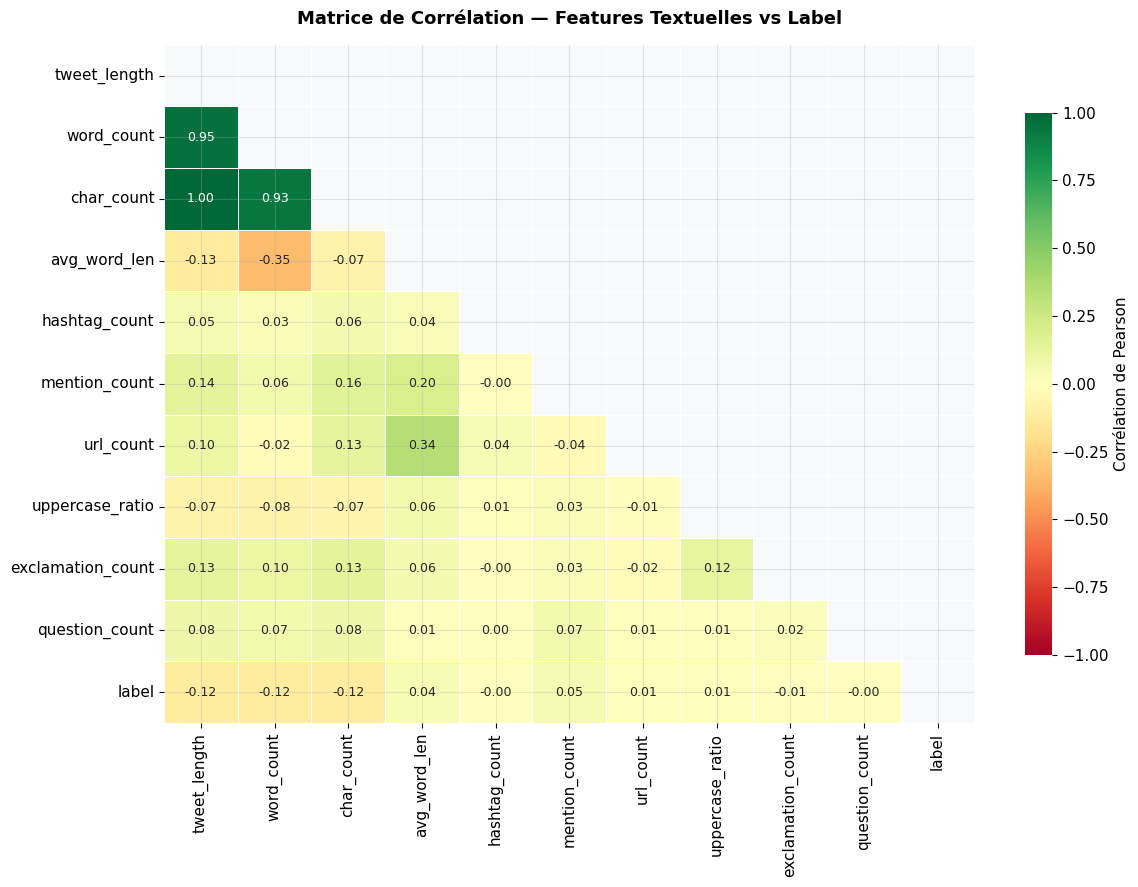

Figure 4 sauvegardée

Top corrélations avec le label :
   word_count             : 0.120
   tweet_length           : 0.120
   char_count             : 0.118
   mention_count          : 0.054
   avg_word_len           : 0.044


In [17]:
# ── Figure 4 : Heatmap de corrélation des features ──────────────────────────
feature_cols = ['tweet_length', 'word_count', 'char_count', 'avg_word_len',
                'hashtag_count', 'mention_count', 'url_count',
                'uppercase_ratio', 'exclamation_count', 'question_count', 'label']

corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 9},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'})

ax.set_title('Matrice de Corrélation — Features Textuelles vs Label',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('/content/reports/figures/fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 sauvegardée')
print()
print('Top corrélations avec le label :')
top_corr = corr_matrix['label'].drop('label').abs().sort_values(ascending=False)
for feat, val in top_corr.head(5).items():
    print(f'   {feat:<22s} : {val:.3f}')

In [19]:
# ── 3.3 Analyse de fréquence des mots (avant prétraitement) ─────────────────
from collections import Counter
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20, exclude_stopwords=False):
    all_words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
        tokens = [t for t in tokens if len(t) > 2]
        if exclude_stopwords:
            tokens = [t for t in tokens if t not in stop_words]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

top_suspect = get_top_words(df[df['label']==1]['message'], exclude_stopwords=True)
top_normal  = get_top_words(df[df['label']==0]['message'], exclude_stopwords=True)

print('TOP 15 MOTS — TWEETS SUSPECTS (hors stop words)')
print('-' * 45)
for word, count in top_suspect[:15]:
    bar = '█' * (count // 1)
    print(f'  {word:<20s} {count:4d}  {bar}')

print()
print('TOP 15 MOTS — TWEETS NORMAUX (hors stop words)')
print('-' * 45)
for word, count in top_normal[:15]:
    bar = '█' * (count // 1)
    print(f'  {word:<20s} {count:4d}  {bar}')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


TOP 15 MOTS — TWEETS SUSPECTS (hors stop words)
---------------------------------------------
  good                 3117  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

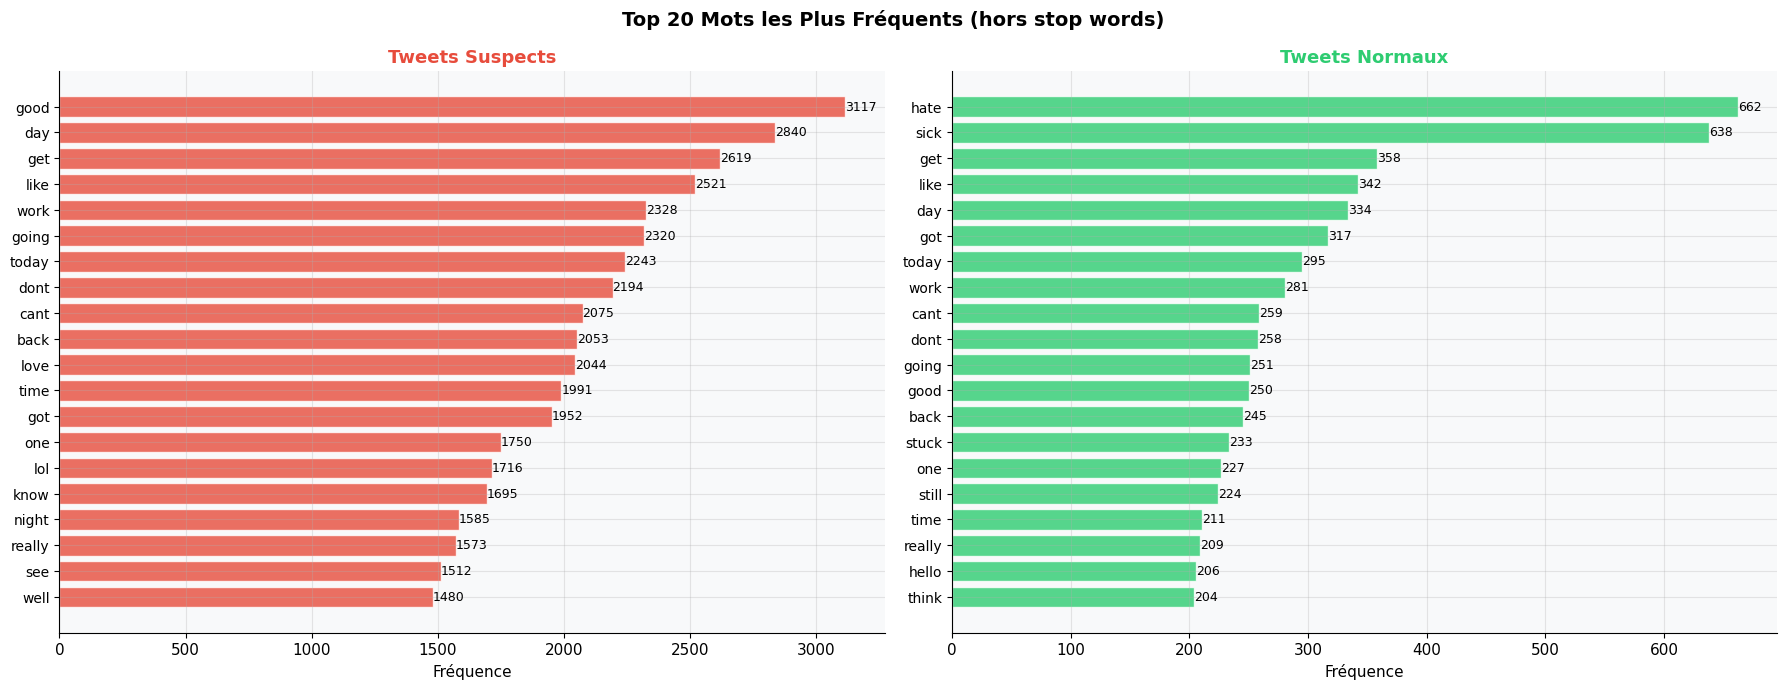

Figure 5 sauvegardée


In [20]:
# ── Figure 5 : Fréquence des mots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 20 Mots les Plus Fréquents (hors stop words)', fontsize=14, fontweight='bold')

for ax, top_words, color, title in [
    (axes[0], top_suspect[:20], COLORS['suspect'], 'Tweets Suspects'),
    (axes[1], top_normal[:20],  COLORS['normal'],  'Tweets Normaux')
]:
    words, counts = zip(*top_words)
    y_pos = range(len(words))
    bars = ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Fréquence')
    ax.set_title(title, color=color, fontweight='bold')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/reports/figures/fig5_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 sauvegardée')

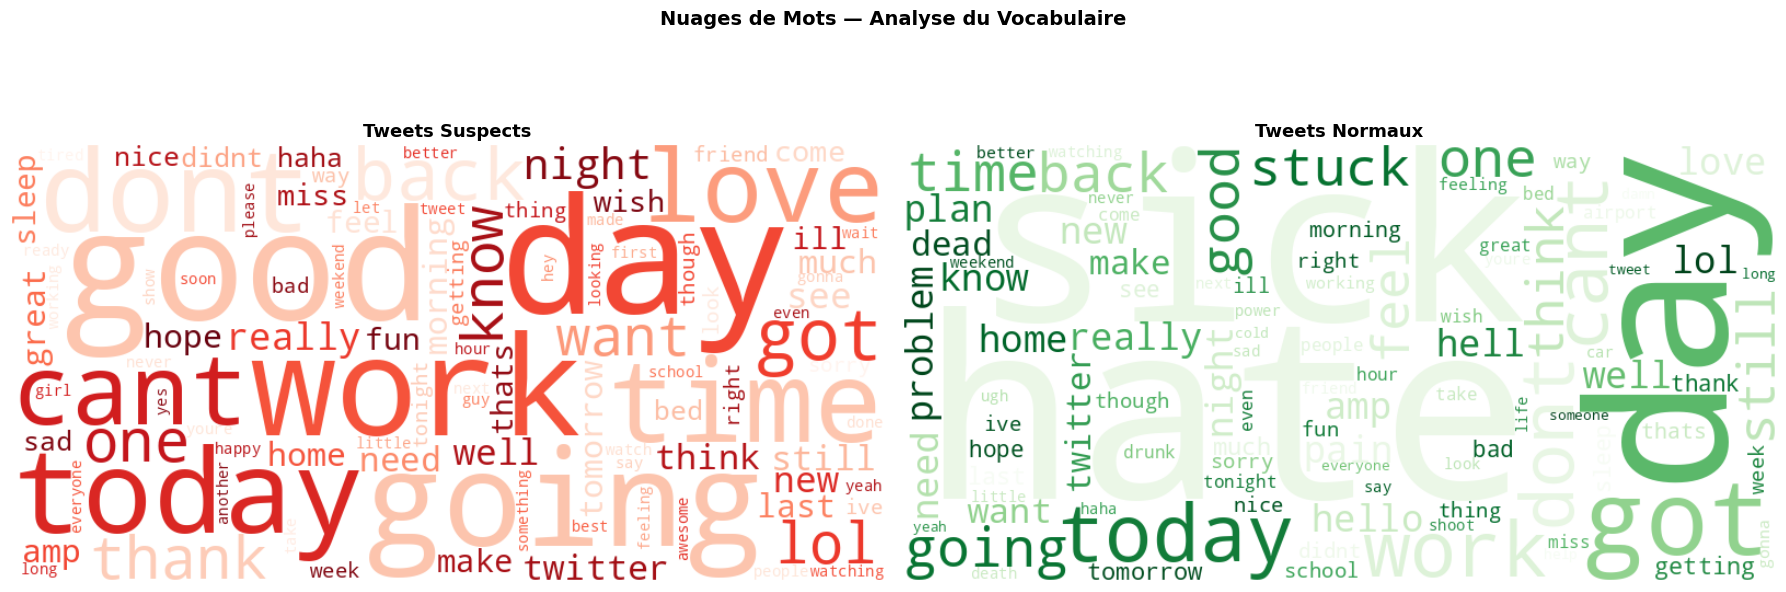

Figure 6 sauvegardée


In [21]:
# ── Figure 6 : Nuages de mots (Word Clouds) ───────────────────────────────────
def generate_text_for_cloud(texts, exclude_sw=True):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
        tokens = [t for t in tokens if len(t) > 2]
        if exclude_sw:
            tokens = [t for t in tokens if t not in stop_words]
        words.extend(tokens)
    return ' '.join(words)

text_suspect = generate_text_for_cloud(df[df['label']==1]['message'])
text_normal  = generate_text_for_cloud(df[df['label']==0]['message'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Nuages de Mots — Analyse du Vocabulaire', fontsize=14, fontweight='bold')

for ax, text, colormap, label in [
    (axes[0], text_suspect, 'Reds',   'Tweets Suspects'),
    (axes[1], text_normal,  'Greens', 'Tweets Normaux')
]:
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        random_state=RANDOM_STATE,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/reports/figures/fig6_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 sauvegardée')

<a id='4'></a>
## 4. Prétraitement du Texte

### Justification des choix

| Étape | Justification |
|-------|---------------|
| **Conversion en minuscules** | Normalisation : "BAD" et "bad" représentent le même concept |
| **Suppression des URLs** | Les URLs sont du bruit pour la classification sémantique |
| **Suppression des mentions @** | Non discriminantes pour la classification du contenu |
| **Suppression des caractères spéciaux** | Réduction du vocabulaire, seuls les tokens lexicaux comptent |
| **Suppression des stop words** | Mots à haute fréquence mais faible valeur sémantique |
| **Lemmatisation** | Regroupe les variantes morphologiques (running→run, hating→hate) |

> **Choix entre Stemming et Lemmatisation** : la lemmatisation a été préférée car elle produit des formes valides du lexique, ce qui est important pour la lisibilité et la qualité des embeddings (Word2Vec, BERT) en Partie 3.

In [27]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4') # Add this line to download Open Multilingual Wordnet
# ── Initialisation du lemmatizer ─────────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))
# Retirer certains mots négatifs importants des stop words
preserve_negations = {'no', 'not', 'never', 'nothing', 'nobody', 'nowhere',
                      'none', 'nor', 'neither', 'cannot', "can't", "won't",
                      'against', 'hate', 'bad', 'worst'}
stop_words_custom = stop_words_en - preserve_negations

print(f'Stop words standard  : {len(stop_words_en)}')
print(f'Stop words personnalisés : {len(stop_words_custom)} (négations préservées)')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Stop words standard  : 198
Stop words personnalisés : 193 (négations préservées)


In [28]:
# ── Fonction de prétraitement complète ───────────────────────────────────────
def preprocess_tweet(text, lemmatize=True):
    """
    Pipeline de prétraitement d'un tweet.

    Étapes :
      1. Conversion en minuscules
      2. Suppression des URLs
      3. Suppression des mentions (@user)
      4. Suppression des hashtags (#tag) — conservation du mot
      5. Suppression des caractères spéciaux et chiffres
      6. Suppression des espaces multiples
      7. Suppression des stop words (avec préservation des négations)
      8. Lemmatisation

    Parameters
    ----------
    text : str
    lemmatize : bool, default=True

    Returns
    -------
    str — texte nettoyé
    """
    if pd.isna(text):
        return ''

    # Étape 1 : minuscules
    text = str(text).lower()

    # Étape 2 : suppression des URLs (http/https/www)
    text = re.sub(r'http\S+|www\.\S+|https\S+', '', text)

    # Étape 3 : suppression des mentions @user
    text = re.sub(r'@\w+', '', text)

    # Étape 4 : suppression du symbole # mais conservation du mot
    text = re.sub(r'#(\w+)', r'\1', text)

    # Étape 5 : suppression des caractères spéciaux et chiffres
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Étape 6 : normalisation des espaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Étape 7 : tokenisation et suppression des stop words
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_custom and len(t) > 1]

    # Étape 8 : lemmatisation
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
        tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]

    return ' '.join(tokens)


# ── Démonstration sur un exemple ─────────────────────────────────────────────
exemples = [
    "@switchfoot http://twitpic.com/2y1zl - Awww, that's a BUMMER!!!",
    "I HATE everyone today!! This is the WORST thing ever #badday",
    "Just had the most amazing breakfast :) feeling SO energized!"
]

print('DÉMONSTRATION DU PIPELINE DE PRÉTRAITEMENT')
print('=' * 70)
for i, ex in enumerate(exemples, 1):
    cleaned = preprocess_tweet(ex)
    print(f'\n  Exemple {i} :')
    print(f'  AVANT  : {ex}')
    print(f'  APRÈS  : {cleaned}')

DÉMONSTRATION DU PIPELINE DE PRÉTRAITEMENT

  Exemple 1 :
  AVANT  : @switchfoot http://twitpic.com/2y1zl - Awww, that's a BUMMER!!!
  APRÈS  : awww bummer

  Exemple 2 :
  AVANT  : I HATE everyone today!! This is the WORST thing ever #badday
  APRÈS  : hate everyone today worst thing ever badday

  Exemple 3 :
  AVANT  : Just had the most amazing breakfast :) feeling SO energized!
  APRÈS  : amaze breakfast feel energize


In [29]:
# ── Application du prétraitement au dataset complet ──────────────────────────
import time

print('Prétraitement en cours...')
start = time.time()

df['message_clean'] = df['message'].apply(preprocess_tweet)

elapsed = time.time() - start
print(f'Prétraitement terminé en {elapsed:.2f}s pour {len(df)} tweets')

# Vérification des tweets vides après nettoyage
empty_after = (df['message_clean'].str.strip() == '').sum()
print(f'   Tweets vides après nettoyage : {empty_after}')
if empty_after > 0:
    df = df[df['message_clean'].str.strip() != ''].reset_index(drop=True)
    print(f'   → Supprimés. Nouveau total : {len(df)}')

print()
print('Aperçu du dataset nettoyé :')
df[['message', 'message_clean', 'label']].head(8)

Prétraitement en cours...
Prétraitement terminé en 8.20s pour 59703 tweets
   Tweets vides après nettoyage : 271
   → Supprimés. Nouveau total : 59432

Aperçu du dataset nettoyé :


,message,message_clean,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda get david carr third day,1
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...,1
2,@Kenichan I dived many times for the ball. Man...,dive many time ball manage save rest go bound,1
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire,0
4,"@nationwideclass no, it's not behaving at all....",no not behave mad see,1
5,@Kwesidei not the whole crew,not whole crew,1
6,Need a hug,need hug,1
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rain bite bite lol fi...,1


In [30]:
# ── Features post-prétraitement ──────────────────────────────────────────────
df['clean_word_count']   = df['message_clean'].apply(lambda x: len(str(x).split()))
df['clean_tweet_length'] = df['message_clean'].apply(len)
df['vocab_reduction']    = 1 - (df['clean_word_count'] / df['word_count'].replace(0, 1))

print('IMPACT DU PRÉTRAITEMENT SUR LA TAILLE DU TEXTE')
print('=' * 55)
print(f'  Longueur moyenne AVANT : {df["tweet_length"].mean():.1f} caractères')
print(f'  Longueur moyenne APRÈS : {df["clean_tweet_length"].mean():.1f} caractères')
print(f'  Réduction moyenne      : {df["vocab_reduction"].mean()*100:.1f}%')
print()
print(f'  Mots/tweet AVANT : {df["word_count"].mean():.1f}')
print(f'  Mots/tweet APRÈS : {df["clean_word_count"].mean():.1f}')

IMPACT DU PRÉTRAITEMENT SUR LA TAILLE DU TEXTE
  Longueur moyenne AVANT : 74.1 caractères
  Longueur moyenne APRÈS : 39.7 caractères
  Réduction moyenne      : 45.3%

  Mots/tweet AVANT : 13.2
  Mots/tweet APRÈS : 7.0


<a id='5'></a>
## 5. Analyse Post-Prétraitement

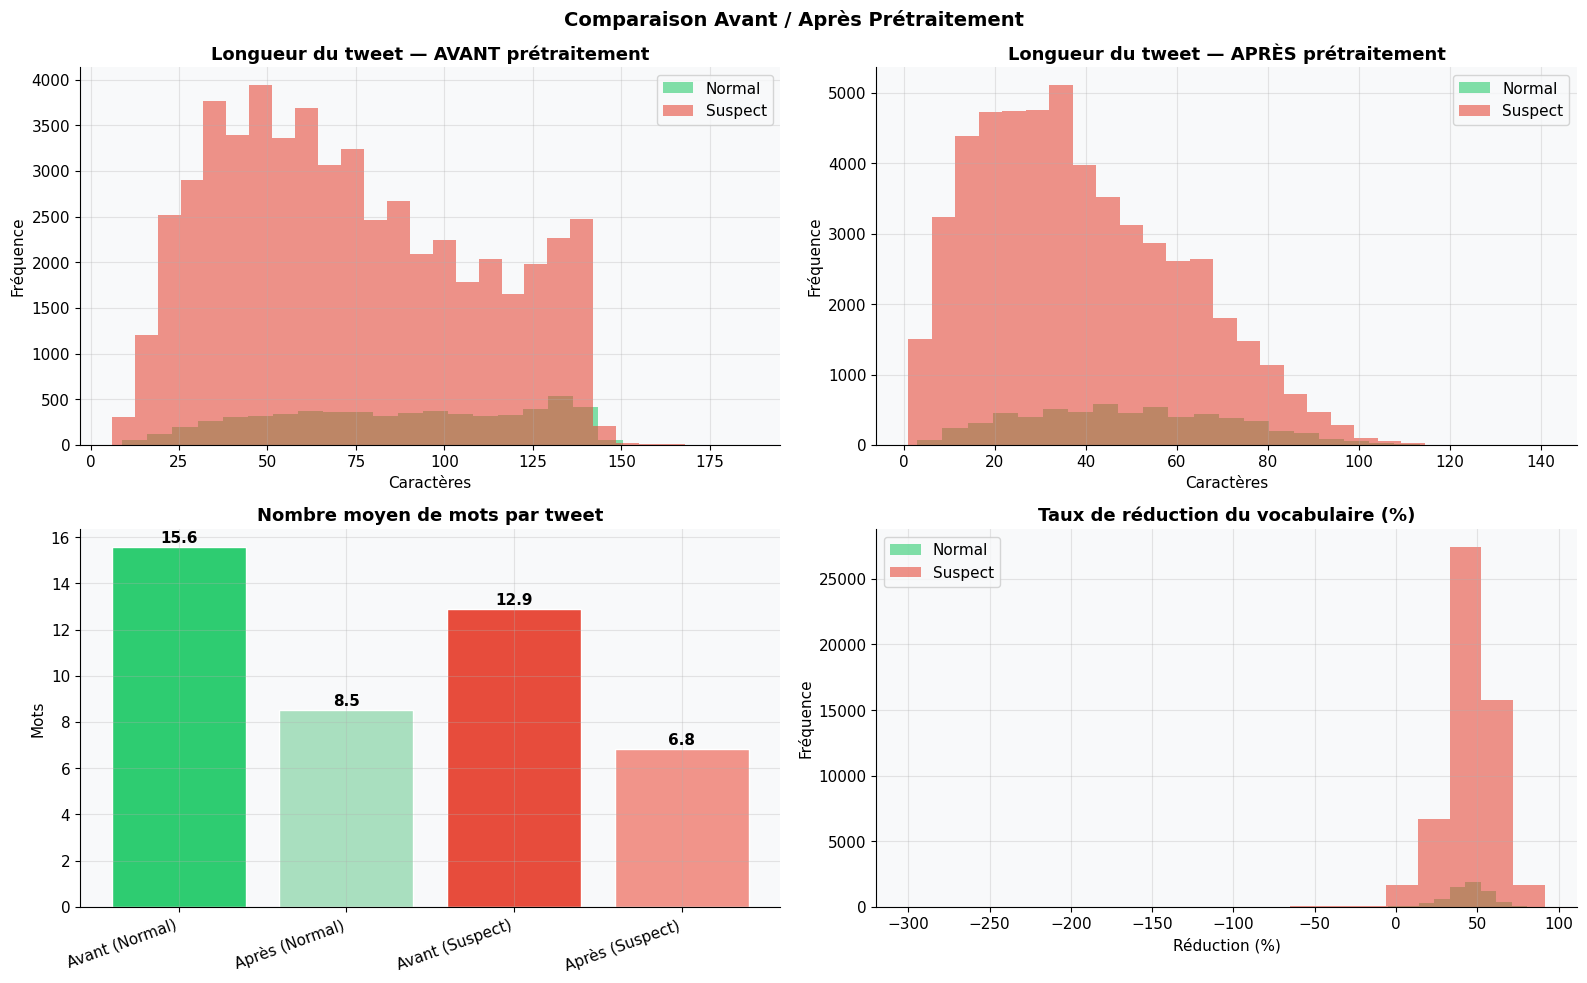

Figure 7 sauvegardée


In [31]:
# ── Figure 7 : Comparaison avant/après prétraitement ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparaison Avant / Après Prétraitement', fontsize=14, fontweight='bold')

# Distribution de la longueur — Avant
ax = axes[0, 0]
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    ax.hist(df[df['label']==lbl]['tweet_length'], bins=25, alpha=0.6, color=color, label=name)
ax.set_title('Longueur du tweet — AVANT prétraitement')
ax.set_xlabel('Caractères'); ax.set_ylabel('Fréquence'); ax.legend()

# Distribution de la longueur — Après
ax = axes[0, 1]
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    ax.hist(df[df['label']==lbl]['clean_tweet_length'], bins=25, alpha=0.6, color=color, label=name)
ax.set_title('Longueur du tweet — APRÈS prétraitement')
ax.set_xlabel('Caractères'); ax.set_ylabel('Fréquence'); ax.legend()

# Nombre de mots — Avant vs Après
ax = axes[1, 0]
categories = ['Avant (Normal)', 'Après (Normal)', 'Avant (Suspect)', 'Après (Suspect)']
values = [
    df[df['label']==0]['word_count'].mean(),
    df[df['label']==0]['clean_word_count'].mean(),
    df[df['label']==1]['word_count'].mean(),
    df[df['label']==1]['clean_word_count'].mean(),
]
bar_colors = [COLORS['normal'], '#A9DFBF', COLORS['suspect'], '#F1948A']
bars = ax.bar(categories, values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', fontweight='bold')
ax.set_title('Nombre moyen de mots par tweet')
ax.set_ylabel('Mots')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

# Taux de réduction par classe
ax = axes[1, 1]
for lbl, color, name in [(0, COLORS['normal'], 'Normal'), (1, COLORS['suspect'], 'Suspect')]:
    ax.hist(df[df['label']==lbl]['vocab_reduction'] * 100, bins=20,
            alpha=0.6, color=color, label=name)
ax.set_title('Taux de réduction du vocabulaire (%)')
ax.set_xlabel('Réduction (%)'); ax.set_ylabel('Fréquence'); ax.legend()

plt.tight_layout()
plt.savefig('/content/reports/figures/fig7_avant_apres_pretraitement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 sauvegardée')

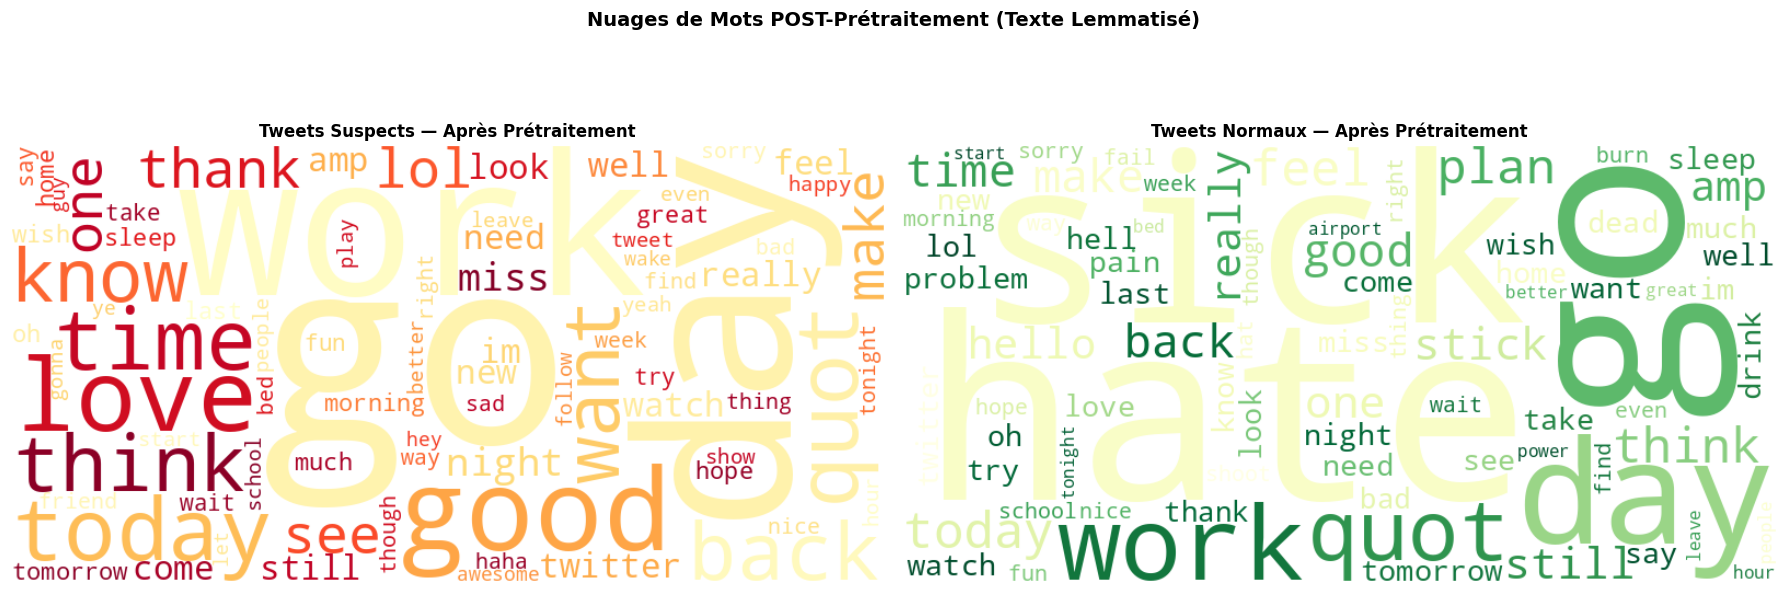

Figure 8 sauvegardée


In [32]:
# ── Figure 8 : Word clouds post-prétraitement ─────────────────────────────────
text_suspect_clean = ' '.join(df[df['label']==1]['message_clean'])
text_normal_clean  = ' '.join(df[df['label']==0]['message_clean'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Nuages de Mots POST-Prétraitement (Texte Lemmatisé)', fontsize=14, fontweight='bold')

for ax, text, colormap, label in [
    (axes[0], text_suspect_clean, 'YlOrRd', 'Tweets Suspects — Après Prétraitement'),
    (axes[1], text_normal_clean,  'YlGn',   'Tweets Normaux — Après Prétraitement')
]:
    wc = WordCloud(
        width=800, height=400, background_color='white',
        colormap=colormap, max_words=80, random_state=RANDOM_STATE,
        collocations=False, min_font_size=8
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/reports/figures/fig8_wordclouds_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 sauvegardée')

In [33]:
# ── Taille du vocabulaire ─────────────────────────────────────────────────────
from collections import Counter

all_tokens_raw   = ' '.join(df['message']).lower().split()
all_tokens_clean = ' '.join(df['message_clean']).split()

vocab_raw   = set(all_tokens_raw)
vocab_clean = set(all_tokens_clean)

print('TAILLE DU VOCABULAIRE')
print('=' * 45)
print(f'  Vocabulaire brut    : {len(vocab_raw):,} tokens uniques')
print(f'  Vocabulaire nettoyé : {len(vocab_clean):,} tokens uniques')
print(f'  Réduction           : {(1 - len(vocab_clean)/len(vocab_raw))*100:.1f}%')
print()
print(f'  Tokens totaux bruts    : {len(all_tokens_raw):,}')
print(f'  Tokens totaux nettoyés : {len(all_tokens_clean):,}')

# Mots distinctifs par classe
words_suspect = set(' '.join(df[df['label']==1]['message_clean']).split())
words_normal  = set(' '.join(df[df['label']==0]['message_clean']).split())
words_shared  = words_suspect & words_normal

print()
print('MOTS DISTINCTIFS PAR CLASSE')
print(f'  Mots exclusifs aux suspects : {len(words_suspect - words_normal)}')
print(f'  Mots exclusifs aux normaux  : {len(words_normal - words_suspect)}')
print(f'  Mots partagés               : {len(words_shared)}')

TAILLE DU VOCABULAIRE
  Vocabulaire brut    : 98,193 tokens uniques
  Vocabulaire nettoyé : 31,047 tokens uniques
  Réduction           : 68.4%

  Tokens totaux bruts    : 782,953
  Tokens totaux nettoyés : 416,046

MOTS DISTINCTIFS PAR CLASSE
  Mots exclusifs aux suspects : 22321
  Mots exclusifs aux normaux  : 2538
  Mots partagés               : 6188


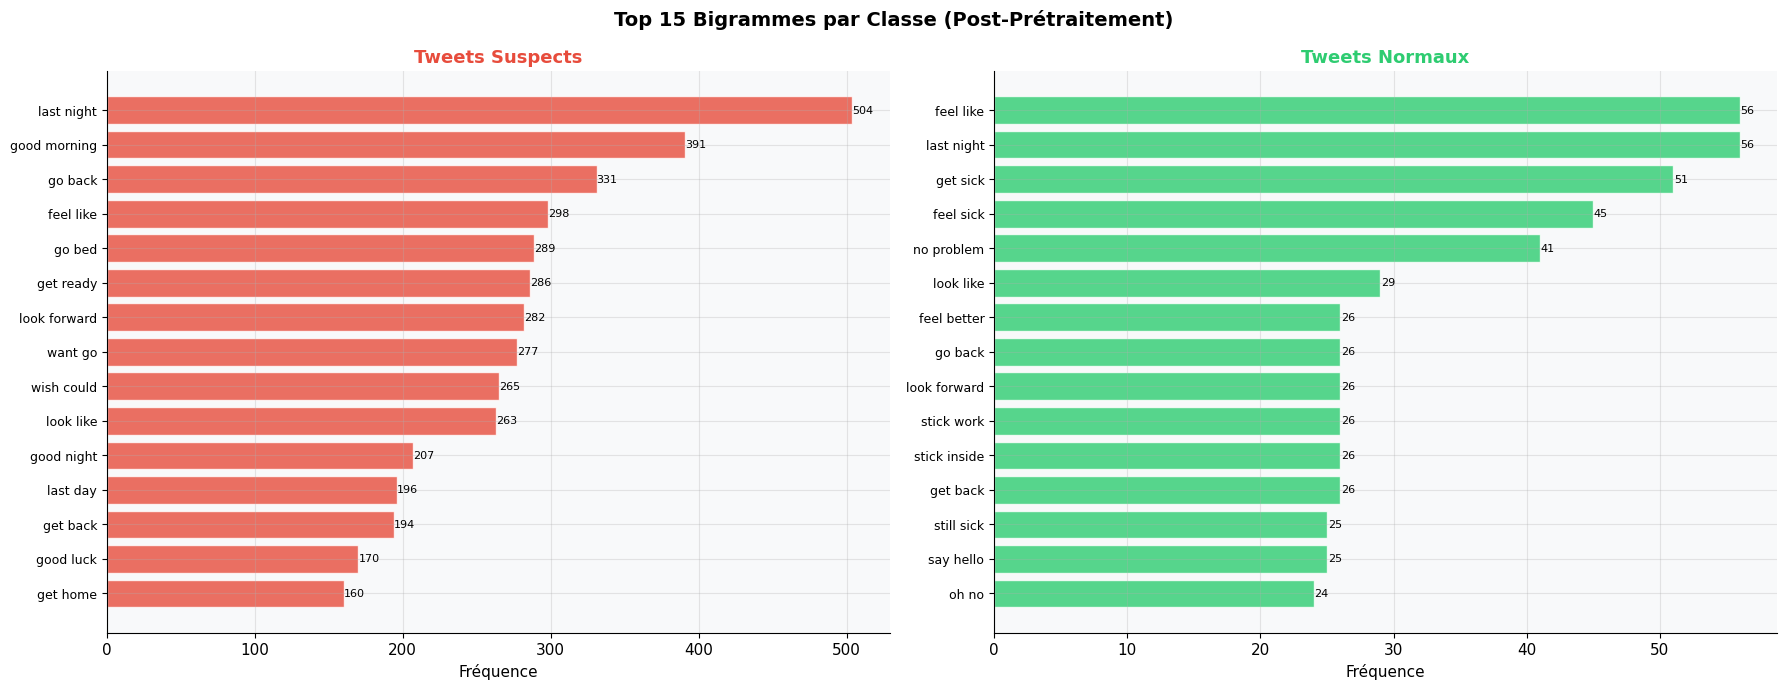

Figure 9 sauvegardée


In [34]:
# ── Figure 9 : N-grammes (bigrammes) ─────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

top_bigrams_suspect = get_top_ngrams(df[df['label']==1]['message_clean'].fillna(''))
top_bigrams_normal  = get_top_ngrams(df[df['label']==0]['message_clean'].fillna(''))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 15 Bigrammes par Classe (Post-Prétraitement)', fontsize=14, fontweight='bold')

for ax, bigrams, color, title in [
    (axes[0], top_bigrams_suspect, COLORS['suspect'], 'Tweets Suspects'),
    (axes[1], top_bigrams_normal,  COLORS['normal'],  'Tweets Normaux')
]:
    if bigrams:
        words, counts = zip(*bigrams)
        y_pos = range(len(words))
        bars = ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=9)
        ax.invert_yaxis()
        ax.set_title(title, color=color, fontweight='bold')
        ax.set_xlabel('Fréquence')
        for bar, count in zip(bars, counts):
            ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/reports/figures/fig9_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 sauvegardée')

<a id='6'></a>
## 6. Sauvegarde des Données Prétraitées

In [36]:
import os

# Define the output directory and create it if it doesn't exist
output_dir = '/content/data/'
os.makedirs(output_dir, exist_ok=True)

# Construct the full output path
output_path = os.path.join(output_dir, 'tweets_suspect_preprocessed.csv')

cols_to_save = [
    'message', 'message_clean', 'label',
    'tweet_length', 'word_count', 'clean_word_count',
    'hashtag_count', 'mention_count', 'url_count',
    'uppercase_ratio', 'exclamation_count', 'question_count'
]

df[cols_to_save].to_csv(output_path, index=False)

print('SAUVEGARDE DES DONNÉES')
print('=' * 55)
print(f'  Fichier : {output_path}')
print(f'  Lignes  : {len(df)}')
print(f'  Colonnes: {len(cols_to_save)}')
print()
print('  Colonnes sauvegardées :')
for col in cols_to_save:
    print(f'    - {col}')

SAUVEGARDE DES DONNÉES
  Fichier : /content/data/tweets_preprocessed.csv
  Lignes  : 59432
  Colonnes: 12

  Colonnes sauvegardées :
    - message
    - message_clean
    - label
    - tweet_length
    - word_count
    - clean_word_count
    - hashtag_count
    - mention_count
    - url_count
    - uppercase_ratio
    - exclamation_count
    - question_count


In [37]:
# ── Récapitulatif final ──────────────────────────────────────────────────────
print('=' * 65)
print('RÉCAPITULATIF — PARTIE 1 : EDA ET PRÉTRAITEMENT')
print('=' * 65)
print()
print('  1️⃣  DATASET')
print(f'     • Total tweets     : {len(df)}')
print(f'     • Tweets suspects  : {(df["label"]==1).sum()} ({(df["label"]==1).mean()*100:.1f}%)')
print(f'     • Tweets normaux   : {(df["label"]==0).sum()} ({(df["label"]==0).mean()*100:.1f}%)')
print(f'     • Valeurs manquantes : 0')
print()
print('  2️⃣  FEATURES TEXTUELLES EXTRAITES')
print(f'     • Longueur moyenne (brute)    : {df["tweet_length"].mean():.0f} caract.')
print(f'     • Longueur moyenne (nettoyée) : {df["clean_tweet_length"].mean():.0f} caract.')
print(f'     • Vocabulaire brut            : {len(vocab_raw):,} tokens')
print(f'     • Vocabulaire nettoyé         : {len(vocab_clean):,} tokens')
print()
print('  3️⃣  PIPELINE DE PRÉTRAITEMENT (dans l\'ordre)')
steps = [
    'Conversion en minuscules',
    'Suppression des URLs (http/https/www)',
    'Suppression des mentions (@user)',
    'Nettoyage des hashtags (# → mot)',
    'Suppression des caractères spéciaux',
    'Normalisation des espaces',
    'Suppression des stop words (avec préservation des négations)',
    'Lemmatisation (verbes + noms — WordNetLemmatizer)'
]
for i, step in enumerate(steps, 1):
    print(f'     {i}. {step}')
print()
print('  4️⃣  VISUALISATIONS PRODUITES')
figures = [
    'fig1_distribution_classes.png',
    'fig2_analyse_longueur.png',
    'fig3_boxplots.png',
    'fig4_correlation_heatmap.png',
    'fig5_top_words.png',
    'fig6_wordclouds.png',
    'fig7_avant_apres_pretraitement.png',
    'fig8_wordclouds_clean.png',
    'fig9_bigrams.png',
]
for fig_name in figures:
    print(f'      {fig_name}')
print()
print('=' * 65)

RÉCAPITULATIF — PARTIE 1 : EDA ET PRÉTRAITEMENT

  1️⃣  DATASET
     • Total tweets     : 59432
     • Tweets suspects  : 53302 (89.7%)
     • Tweets normaux   : 6130 (10.3%)
     • Valeurs manquantes : 0

  2️⃣  FEATURES TEXTUELLES EXTRAITES
     • Longueur moyenne (brute)    : 74 caract.
     • Longueur moyenne (nettoyée) : 40 caract.
     • Vocabulaire brut            : 98,193 tokens
     • Vocabulaire nettoyé         : 31,047 tokens

  3️⃣  PIPELINE DE PRÉTRAITEMENT (dans l'ordre)
     1. Conversion en minuscules
     2. Suppression des URLs (http/https/www)
     3. Suppression des mentions (@user)
     4. Nettoyage des hashtags (# → mot)
     5. Suppression des caractères spéciaux
     6. Normalisation des espaces
     7. Suppression des stop words (avec préservation des négations)
     8. Lemmatisation (verbes + noms — WordNetLemmatizer)

  4️⃣  VISUALISATIONS PRODUITES
      fig1_distribution_classes.png
      fig2_analyse_longueur.png
      fig3_boxplots.png
      fig4_correlat